<a href="https://colab.research.google.com/github/tisenres/amity-aiml303/blob/main/Lab_Implementing_Attention_Mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing Attention Mechanisms

## Objective
In this lab, you will implement **basic attention** and **self-attention** layers from scratch in PyTorch, then apply attention to a **real-world text dataset**.

Attention mechanisms are foundational to modern deep learning architectures (especially Transformers), and understanding them at the tensor level is essential for advanced ML work.

## Learning Objectives
By the end of this lab, you should be able to:

- Understand the **scaled dot-product attention** equation
- Implement a `BasicAttention` module in PyTorch
- Implement a multi-head `SelfAttention` module in PyTorch
- Run attention on a small real-world text classification task
- Interpret attention output and attention weight shapes
- Visualize attention maps for model interpretation

In [ ]:
# ============================================================
# Cell: Imports and environment setup
# ============================================================
import math
import re

from collections import Counter
from urllib.request import urlopen

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility for consistent outputs
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("Device available:", "cuda" if torch.cuda.is_available() else "cpu")

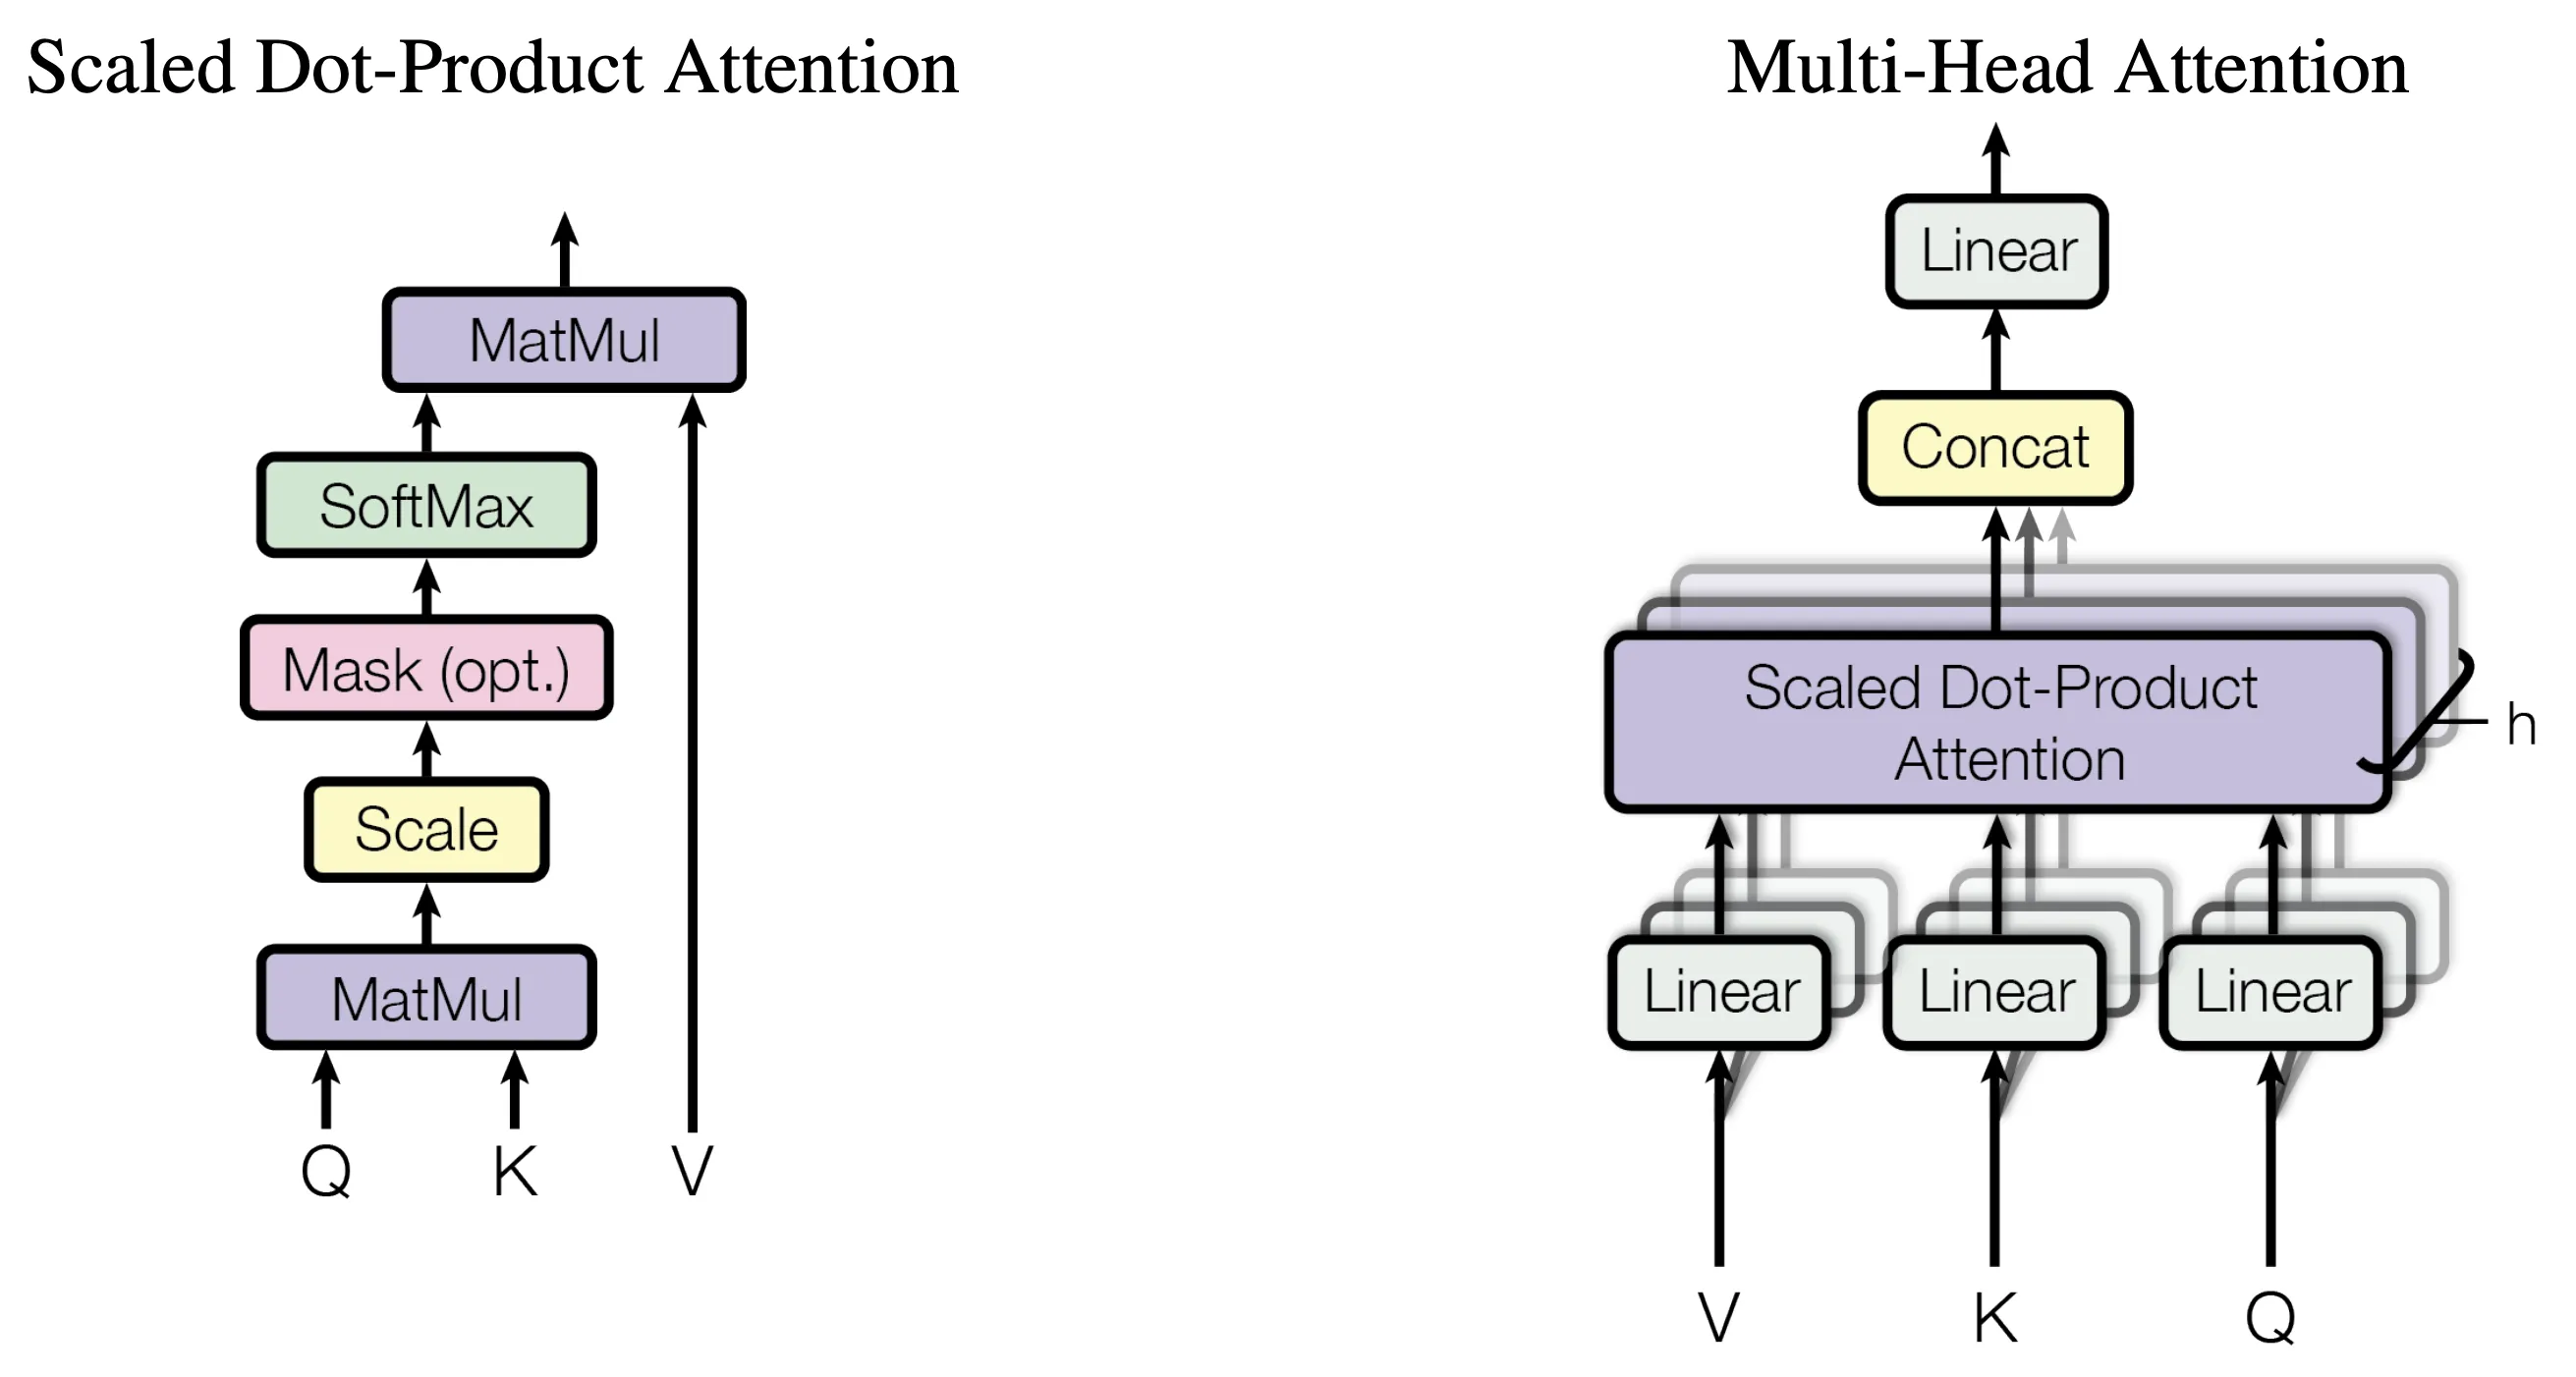

## Tutorial Section

### 1) Scaled Dot-Product Attention (Concept)

Given query $Q$, key $K$, and value $V$, attention is:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

Where:

- $Q \in \mathbb{R}^{B \times L_q \times d_k}$
- $K \in \mathbb{R}^{B \times L_k \times d_k}$
- $V \in \mathbb{R}^{B \times L_k \times d_v}$
- $B$: batch size, $L$: sequence length, $d_k$: key dimension

The scaling factor $\sqrt{d_k}$ prevents dot-product magnitudes from becoming too large, which would push softmax into saturated regions and reduce gradient quality.

In [ ]:
# ============================================================
# Cell: BasicAttention implementation (scaled dot-product)
# ============================================================
class BasicAttention(nn.Module):
    """
    Basic scaled dot-product attention.
    This module assumes query, key, and value are already projected
    to appropriate dimensions.
    """

    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: Tensor of shape (batch_size, q_len, d_k)
            key:   Tensor of shape (batch_size, k_len, d_k)
            value: Tensor of shape (batch_size, k_len, d_v)
            mask:  Optional mask broadcastable to (batch_size, q_len, k_len),
                   where 0 = masked positions.

        Returns:
            context: Tensor of shape (batch_size, q_len, d_v)
            attn_weights: Tensor of shape (batch_size, q_len, k_len)
        """
        # Compute raw similarity scores: QK^T
        scores = torch.matmul(query, key.transpose(-2, -1))  # (B, q_len, k_len)

        # Scale by sqrt(d_k)
        d_k = query.size(-1)
        scores = scores / math.sqrt(d_k)

        # Apply mask (if provided): masked positions receive very negative scores
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Normalize scores into probabilities
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Weighted sum over values
        context = torch.matmul(attn_weights, value)  # (B, q_len, d_v)

        return context, attn_weights

### 2) Multi-Head Self-Attention (Concept)

In self-attention, $Q$, $K$, and $V$ are all derived from the same input $X$.

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

For multi-head attention with $h$ heads:

$$
\text{head}_i = \text{Attention}(Q_i, K_i, V_i)
$$
$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W_O
$$

This allows the model to attend to different representation subspaces in parallel.

In [ ]:
# ============================================================
# Cell: SelfAttention implementation (multi-head capable)
# ============================================================
class SelfAttention(nn.Module):
    """
    Multi-head self-attention layer from scratch.
    """

    def __init__(self, d_model=64, num_heads=4, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Linear projections for Q, K, V and output projection
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.attn = BasicAttention(dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x):
        """
        Split (B, L, d_model) -> (B, num_heads, L, head_dim)
        """
        B, L, _ = x.size()
        x = x.view(B, L, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)  # (B, H, L, D_h)
        return x

    def _combine_heads(self, x):
        """
        Combine (B, num_heads, L, head_dim) -> (B, L, d_model)
        """
        B, H, L, D_h = x.size()
        x = x.transpose(1, 2).contiguous()  # (B, L, H, D_h)
        x = x.view(B, L, H * D_h)          # (B, L, d_model)
        return x

    def forward(self, x, mask=None):
        """
        Args:
            x: Tensor of shape (batch_size, seq_len, d_model)
            mask: Optional mask broadcastable to (batch_size, num_heads, seq_len, seq_len)
                  or (batch_size, 1, seq_len, seq_len)

        Returns:
            output: Tensor of shape (batch_size, seq_len, d_model)
            attn_weights: Tensor of shape (batch_size, num_heads, seq_len, seq_len)
        """
        # Project input to Q, K, V
        q = self.w_q(x)  # (B, L, d_model)
        k = self.w_k(x)
        v = self.w_v(x)

        # Split into heads
        q = self._split_heads(q)  # (B, H, L, D_h)
        k = self._split_heads(k)
        v = self._split_heads(v)

        # Flatten heads into batch dimension to reuse BasicAttention
        B, H, L, D_h = q.shape
        q_flat = q.reshape(B * H, L, D_h)
        k_flat = k.reshape(B * H, L, D_h)
        v_flat = v.reshape(B * H, L, D_h)

        # Prepare mask for flattened batch if provided
        if mask is not None:
            # Expected mask shape after broadcast: (B, H, L, L)
            if mask.dim() == 3:  # (B, L, L) -> (B, 1, L, L)
                mask = mask.unsqueeze(1)
            mask = mask.expand(B, H, L, L).reshape(B * H, L, L)

        # Apply scaled dot-product attention per head
        context_flat, attn_weights_flat = self.attn(q_flat, k_flat, v_flat, mask=mask)

        # Restore head dimension
        context = context_flat.view(B, H, L, D_h)
        attn_weights = attn_weights_flat.view(B, H, L, L)

        # Concatenate heads and project out
        combined = self._combine_heads(context)  # (B, L, d_model)
        output = self.w_o(self.dropout(combined))

        return output, attn_weights

### 3) Forward Pass Demo with Example Tensors

We now run both modules with:

- `batch_size = 2`
- `seq_len = 10`
- `d_model = 64`
- `heads = 4`

In [ ]:
# ============================================================
# Cell: Demo tensors + forward pass
# ============================================================
# Example dimensions
batch_size = 2
seq_len = 10
d_model = 64
num_heads = 4

# Random input sequence
x = torch.randn(batch_size, seq_len, d_model)

# --- BasicAttention demo ---
# For BasicAttention, we directly supply Q, K, V
q = torch.randn(batch_size, seq_len, d_model)
k = torch.randn(batch_size, seq_len, d_model)
v = torch.randn(batch_size, seq_len, d_model)

basic_attn = BasicAttention(dropout=0.0)
basic_context, basic_weights = basic_attn(q, k, v)

print("=== BasicAttention ===")
print("Input q shape:          ", q.shape)
print("Attention weights shape:", basic_weights.shape)   # (B, L, L)
print("Context output shape:   ", basic_context.shape)   # (B, L, d_model)

# --- SelfAttention demo ---
self_attn = SelfAttention(d_model=d_model, num_heads=num_heads, dropout=0.0)
self_output, self_weights = self_attn(x)

print("\n=== SelfAttention (Multi-Head) ===")
print("Input x shape:          ", x.shape)
print("Attention weights shape:", self_weights.shape)    # (B, H, L, L)
print("Output shape:           ", self_output.shape)     # (B, L, d_model)

In [ ]:
# ============================================================
# Cell: Attention weight visualization (heatmap)
# ============================================================
# Visualize one attention map:
# - sample index = 0
# - head index = 0
sample_idx = 0
head_idx = 0

attn_map = self_weights[sample_idx, head_idx].detach().cpu().numpy()  # (L, L)

plt.figure(figsize=(6, 5))
plt.imshow(attn_map, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.title(f"Self-Attention Heatmap (sample={sample_idx}, head={head_idx})")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.tight_layout()
plt.show()

## Real-World Mini Project: Attention for News Topic Classification

Now we use a **real-world dataset** (AG News headlines) to build a tiny text classifier with self-attention.

### What we will do
- Download a small subset of AG News data
- Build a simple tokenizer and vocabulary
- Convert text to integer token IDs
- Train a small `SelfAttention`-based classifier
- Evaluate accuracy and inspect one attention map

> We keep this intentionally small and beginner-friendly so it runs quickly in Colab/Jupyter.

### 4) Load a Real-World Dataset (AG News)

We will use the **AG News** text dataset (news headlines labeled into 4 classes):

1. World
2. Sports
3. Business
4. Sci/Tech

To keep runtime short for beginners, we use a small subset.

> If internet is unavailable, skip this section and continue with random-tensor demonstrations above.

In [ ]:
# ============================================================
# Cell: Download and parse AG News subset
# ============================================================
import csv
from io import StringIO

TRAIN_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
TEST_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"


def load_ag_news_from_url(url, max_rows=2000):
    """Download CSV text and return (texts, labels) lists.
    Labels are converted from 1..4 to 0..3.
    """
    raw = urlopen(url).read().decode("utf-8")
    reader = csv.reader(StringIO(raw))

    texts, labels = [], []
    for i, row in enumerate(reader):
        if i >= max_rows:
            break
        # Row format: [label, title, description]
        label = int(row[0]) - 1
        title = row[1]
        desc = row[2] if len(row) > 2 else ""
        text = f"{title} {desc}".strip()

        texts.append(text)
        labels.append(label)

    return texts, labels

# Small subsets for quick training
train_texts, train_labels = load_ag_news_from_url(TRAIN_URL, max_rows=1500)
test_texts, test_labels = load_ag_news_from_url(TEST_URL, max_rows=400)

label_names = ["World", "Sports", "Business", "Sci/Tech"]

print(f"Train samples: {len(train_texts)}")
print(f"Test samples:  {len(test_texts)}")
print("Sample text:", train_texts[0][:120], "...")
print("Sample label:", train_labels[0], "->", label_names[train_labels[0]])

In [ ]:
# ============================================================
# Cell: Tokenization, vocabulary, and tensorization
# ============================================================

def simple_tokenize(text):
    """Lowercase + keep alphabetic tokens and apostrophes."""
    return re.findall(r"[a-z']+", text.lower())


def build_vocab(texts, max_vocab_size=5000, min_freq=2):
    """Create token->id mapping with PAD=0, UNK=1."""
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for token, freq in counter.most_common(max_vocab_size):
        if freq < min_freq:
            continue
        if token not in vocab:
            vocab[token] = len(vocab)

    return vocab


def encode_text(text, vocab, max_len=20):
    """Convert text to fixed-length token IDs."""
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]

    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))

    return ids

max_len = 20
vocab = build_vocab(train_texts, max_vocab_size=5000, min_freq=2)

X_train = torch.tensor([encode_text(t, vocab, max_len=max_len) for t in train_texts], dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_test = torch.tensor([encode_text(t, vocab, max_len=max_len) for t in test_texts], dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128)

print("Vocab size:", len(vocab))
print("X_train shape:", X_train.shape)  # (N, max_len)
print("X_test shape:", X_test.shape)

In [ ]:
# ============================================================
# Cell: Simple self-attention classifier + quick training
# ============================================================
class TinyAttentionClassifier(nn.Module):
    """Embedding -> SelfAttention -> mean pooling -> linear classifier."""

    def __init__(self, vocab_size, d_model=64, num_heads=4, num_classes=4, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.self_attn = SelfAttention(d_model=d_model, num_heads=num_heads, dropout=0.1)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, token_ids):
        # token_ids: (B, L)
        x = self.embedding(token_ids)  # (B, L, d_model)

        # Padding mask: 1 for real tokens, 0 for pads
        valid = (token_ids != self.pad_id).float()  # (B, L)
        # Key-only mask: block attention TO pad keys only.
        # Do NOT use valid[i]*valid[j] for all (i,j): pad query rows become all-masked,
        # softmax is all -inf -> NaN loss.
        attn_mask = valid.unsqueeze(1)  # (B, 1, L) broadcasts to (B, L, L)

        attn_out, attn_weights = self.self_attn(x, mask=attn_mask)
        attn_out = attn_out * valid.unsqueeze(-1)  # clear pad positions after attention

        # Mean pooling over non-pad tokens only
        valid_count = valid.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = (attn_out * valid.unsqueeze(-1)).sum(dim=1) / valid_count

        logits = self.classifier(pooled)
        return logits, attn_weights


def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total if total > 0 else 0.0


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyAttentionClassifier(vocab_size=len(vocab), d_model=64, num_heads=4, num_classes=4, pad_id=vocab["<PAD>"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Quick beginner-friendly training loop
epochs = 40
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    test_acc = evaluate_accuracy(model, test_loader, device)
    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.4f}")

In [ ]:
# ============================================================
# Cell: Inspect predictions + visualize attention on real text
# ============================================================
# Build reverse vocab for quick token display
id_to_token = {idx: tok for tok, idx in vocab.items()}

# Take one example from test set
sample_ids = X_test[0].unsqueeze(0).to(device)  # (1, L)
true_label = y_test[0].item()

model.eval()
with torch.no_grad():
    sample_logits, sample_attn = model(sample_ids)
    pred_label = sample_logits.argmax(dim=1).item()

print("True label:", label_names[true_label])
print("Pred label:", label_names[pred_label])

# Tokens (without PAD)
sample_tokens = [id_to_token.get(i, "<UNK>") for i in sample_ids[0].cpu().tolist() if i != vocab["<PAD>"]]
print("Tokens:", sample_tokens)

# Attention map from first head
attn_map = sample_attn[0, 0].detach().cpu().numpy()  # (L, L)
valid_len = len(sample_tokens)
attn_map = attn_map[:valid_len, :valid_len]

plt.figure(figsize=(7, 6))
plt.imshow(attn_map, cmap="magma", aspect="auto")
plt.colorbar(label="Attention weight")
plt.xticks(range(valid_len), sample_tokens, rotation=90)
plt.yticks(range(valid_len), sample_tokens)
plt.title("Attention Heatmap (Real AG News Sample, Head 0)")
plt.tight_layout()
plt.show()

## ✅ Tutorial Complete

### Key Takeaways
- Scaled dot-product attention computes similarity via $QK^\top$, scales scores by $\sqrt{d_k}$, and then aggregates value vectors.
- Multi-head self-attention lets the model focus on different token relationships in parallel.
- We applied attention to a **real-world AG News dataset** and trained a tiny end-to-end classifier.
- Attention heatmaps help us inspect which words influence predictions the most.

## Tasks Section - Student Exercises (Total: 100 points)

Complete **exactly two tasks**, each worth **50 points**.
These tasks directly extend the tutorial implementation.

### Task 1 (50 points): Build a Simple Text-to-ID Pipeline (Real AG News Data)

#### Task Description
Complete the beginner-friendly preprocessing helpers for the AG News dataset:
1. Tokenize text into lowercase words
2. Convert tokens to IDs using `vocab`
3. Pad/truncate to `max_len`

This is the same pipeline used in the tutorial model.

#### Point Breakdown
- Tokenization line completed correctly: **15 points**
- Token-to-ID conversion line completed correctly: **20 points**
- Padding/truncation logic completed correctly: **15 points**

#### Expected Output / Test Case
For `max_len = 8`:
- Encoded output should always have length `8`
- Output should be a list of integers
- Unknown words should map to `vocab["<UNK>"]`

#### Grading Rubric

| Criterion | Excellent (full) | Partial | None |
|---|---|---|---|
| Tokenization | Correct lowercase + word tokenization | Minor tokenization issue | Not implemented |
| ID mapping | Correct vocab lookup with UNK fallback | Occasional lookup mistakes | Not implemented |
| Padding/truncation | Output length always equals `max_len` | One edge case fails | Not implemented |

In [ ]:
# ============================================================
# Cell: Task 1 starter code (SOLVED)
# ============================================================
# Goal: complete a simple AG News preprocessing pipeline.

def task1_tokenize(text):
    """Convert text to lowercase word tokens."""
    # [15 pts]: complete this line using regex
    # extracts word-like chunks (letters + apostrophe)
    tokens = re.findall(r"[a-z']+", text.lower())
    return tokens

def task1_encode_text(text, vocab, max_len=8):
    """Convert text into exactly max_len IDs."""
    tokens = task1_tokenize(text)

    # [20 pts]: map each token to an ID, fallback to <UNK>
    # Truncate tokens to max_len first to simplify logic
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]

    # [15 pts]: pad with <PAD> until length == max_len
    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))

    return ids

In [ ]:
# ============================================================
# Cell: Task 1 test scaffold
# ============================================================
# Run this cell only after completing TODOs in Task 1 starter code.
sample_text = "New technology company launches AI product"
encoded = task1_encode_text(sample_text, vocab, max_len=8)

print("Encoded IDs:", encoded)
print("Expected: a list of 8 integer token IDs")

### Task 2 (50 points): Run Inference on Real News and Read Attention

#### Task Description
Use the trained tutorial model to:
1. Predict the class for one AG News test sample
2. Print predicted class name and true class name
3. Find which token receives the highest average attention (head 0)

This task focuses on **using** attention outputs rather than writing advanced modules.

#### Point Breakdown
- Correct prediction extraction with `argmax`: **20 points**
- Correct label-name mapping and print statements: **15 points**
- Correct top-attended token extraction: **15 points**

#### Expected Output / Test Case
- You should see one true class and one predicted class string
- You should see one token reported as "top attended"
- Code should run on a single sample from `X_test`

#### Grading Rubric

| Criterion | Excellent (full) | Partial | None |
|---|---|---|---|
| Prediction step | Correct `argmax` prediction | Minor tensor/index bug | Not implemented |
| Label interpretation | Correct class-name lookup | One mismatch in lookup | Not implemented |
| Attention interpretation | Correct top token from attention scores | Logic partly correct | Not implemented |

In [ ]:
# ============================================================
# Cell: Task 2 starter code (SOLVED)
# ============================================================
# Pick one test example
task2_idx = 5
x_one = X_test[task2_idx].unsqueeze(0).to(device)  # (1, L)
y_true = y_test[task2_idx].item()

model.eval()
with torch.no_grad():
    logits_one, attn_one = model(x_one)

# [20 pts]: get predicted class index using argmax
y_pred = logits_one.argmax(dim=1).item()

# [15 pts]: map class indices to class names
true_name = label_names[y_true]
pred_name = label_names[y_pred]

print("True class:", true_name)
print("Pred class:", pred_name)

# Build token list without PAD
tokens_one = [id_to_token.get(i, "<UNK>") for i in x_one[0].cpu().tolist() if i != vocab["<PAD>"]]

# Attention from head 0, shape (L, L)
# We slice it to the actual number of tokens (excluding padding)
attn_h0 = attn_one[0, 0].detach().cpu()[:len(tokens_one), :len(tokens_one)]

# [15 pts]: find token with highest average incoming attention
# We average across the 'query' dimension (dim=0) to see which 'key' (dim=1) is most attended to
avg_attn_per_token = attn_h0.mean(dim=0)
top_token_idx = avg_attn_per_token.argmax().item()
top_token = tokens_one[top_token_idx]

print("Top attended token (head 0):", top_token)

In [ ]:
# ============================================================
# Cell: Task 2 test scaffold
# ============================================================
# Run this cell after completing Task 2 TODOs.
print("Task 2 checks:")
print("- true/pred class names are actual labels (not None)")
print("- top attended token is a real token string")
print("- outputs come from one AG News sample")

## Bonus: Theoretical Questions (10% extra credit)

Answer the following short questions.  
These are worth **10% bonus in total**.

1. In simple words, why do we divide attention scores by $\sqrt{d_k}$?
2. In this AG News example, why might attention focus more on words like team, market, or software?
3. What is one advantage of using multiple attention heads instead of only one?

### Bonus: Theoretical Answers

1. **Scaling by $\sqrt{d_k}$**: We divide by the square root of the dimension to prevent the dot products from growing very large in magnitude. Large values would cause the `softmax` function to enter regions with extremely small gradients (saturation), making the model much harder to train.

2. **Focus on specific words**: In news classification, words like "team" (Sports), "market" (Business), or "software" (Sci/Tech) carry high semantic weight for distinguishing the topic. The self-attention mechanism learns that these specific tokens are highly relevant "keys" for the classification task, resulting in higher attention weights.

3. **Multiple Heads**: One advantage is that it allows the model to attend to different types of relationships simultaneously. For example, one head might focus on syntactic relationships (grammar), while another focuses on semantic relationships (meaning), providing a richer representation of the text than a single head could.

## End of Lab

You now have:
- A complete guided tutorial implementation
- Two graded coding tasks (50 + 50 points)
- A bonus theoretical section (10% extra credit)

Suggested next step: run all tutorial cells first, then complete Task 1 and Task 2 TODOs and re-run their test cells.